In [10]:
import pandas as pd
import numpy as np



import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn import datasets



from scipy.cluster.hierarchy import dendrogram, linkage

import seaborn as sns

#Importation des fichiers
df_themes = pd.read_csv("courses_info.csv")
df_cours = pd.read_csv("my_courses.csv")
df_textes = pd.read_csv("bag_of_words.csv")
df_mystery = pd.read_csv("mystery.csv")

In [6]:
df_cours.head()

,titreCours,inscription,progression,moyenneDeClasse,duree,difficulte,nbChapitres,ratioQuizEvaluation,nbEvaluations,derniereMiseAJour,idCours
0,Classez_et_segmentez_des_données_visuelles,29,34,NaN,15.0,3,11,0.666667,3,22,4470531
1,Initiez-vous_à_la_statistique_inférentielle,55,4,86.0,12.0,2,21,0.750000,4,8,4525306
2,Maîtrisez_les_bases_des_probabilités,60,100,NaN,NaN,1,1,NaN,0,89,4525296
3,Découvrez_les_librairies_Python_pour_la_Data_S...,64,64,96.0,10.0,2,8,0.000000,2,57,4452741
4,Devenez_mentor_sur_OpenClassrooms,76,100,91.0,6.0,1,12,1.000000,3,29,3595541


In [7]:
df_themes.head()

,title,charge-e-de-gestion-des-ressources-humaines,manager-rh,gestionnaire-de-paie,data-architect,developpeur-se-dapplication-python,developpeur-web-junior,community-manager,responsable-marketing-operationnel,developpeur-se-d-application-php-symfony,data-scientist,expert-e-en-strategie-marketing-et-communication,data-analyst,theme
0,Apprenez à gérer les conflits,True,True,True,False,False,False,False,False,False,False,False,False,RH
1,Réalisez des calculs distribués sur des donnée...,False,False,False,True,False,False,False,False,False,False,False,False,data
2,Managez une équipe au quotidien,False,True,False,False,False,False,False,False,False,False,False,False,RH
3,Gérez votre code avec Git et GitHub,False,False,False,False,True,True,False,False,False,False,False,False,dev
4,Lancez une campagne de publicité avec Google A...,False,False,False,False,False,False,True,True,False,False,False,False,marketing


In [8]:
df_textes.head()

,titre,aaaa,abandonner,abattement,abbr,abc,abondement,abonnement,abonner,abonnés,...,évoqué,évoquées,évoqués,évènement,évènements,événement,événements,êtres,œil,œuvre
0,Concevez des architectures Big Data,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0000,0.0,0.000469,0.000000,0.000000,0.000000
1,Apprenez à coder avec JavaScript,0.000000,0.0,0.0,0.0,0.000499,0.0,0.0,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0001,0.0,0.000000,0.000000,0.000000,0.000000
2,Concevez votre site web avec PHP et MySQL,0.000524,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0000,0.0,0.000000,0.000000,0.000087,0.000000
3,Réussir sa campagne d'e-mailing avec MailChimp,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.020408,0.020408,...,0.0,0.0,0.0,0.0,0.0000,0.0,0.000000,0.000000,0.000000,0.000000
4,Utilisez des modèles supervisés non linéaires,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0000,0.0,0.000000,0.000325,0.000000,0.000651


In [9]:
df_mystery.head()

,0,1,2
0,-7.988979,15.633928,-5.726221
1,0.108386,-3.456144,22.272791
2,1.565447,10.915797,29.040207
3,0.765086,35.831929,20.892023
4,-8.880745,20.989331,8.337199


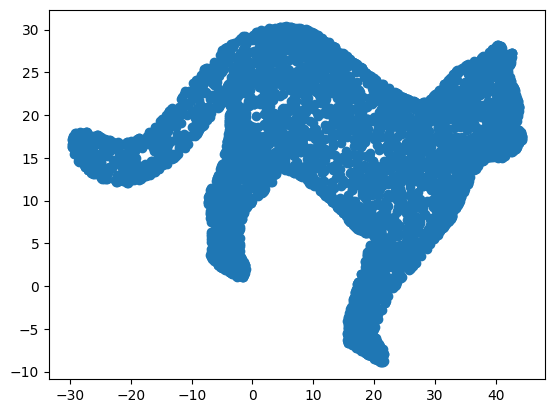

In [10]:
plt.scatter(data=df_mystery, x='1', y='2')

In [11]:
v1 = [12, 3, 12, 8, 12, 5]
v2 = [-42, 3, 12, 80, 1, 78]

In [12]:
v1_mean = sum(v1)/len(v1)
v2_mean = sum(v2)/len(v2)

In [13]:
v1_var = sum([abs(i-v1_mean)**2 for i in v1]) / len(v1)
v2_var = sum([abs(i-v2_mean)**2 for i in v2]) / len(v2)

In [14]:
print(v1_var)
print(v2_var)

13.222222222222221
1916.3333333333333


In [15]:
print(np.var(v1))

13.222222222222221


In [17]:
# Notre matrice de base : 
X = [[12,    30,    80,  -100],
     [-1000, 12,    -23,  10],
     [14,    1000,  0,    0]]

# Version numpy : 
X = np.asarray(X)

# Version pandas : 
X = pd.DataFrame(X)

In [18]:
X

,0,1,2,3
0,12,30,80,-100
1,-1000,12,-23,10
2,14,1000,0,0


In [19]:
X.describe()

,0,1,2,3
count,3.000000,3.000000,3.000000,3.000000
mean,-324.666667,347.333333,19.000000,-30.000000
std,584.856678,565.297562,54.064776,60.827625
min,-1000.000000,12.000000,-23.000000,-100.000000
25%,-494.000000,21.000000,-11.500000,-50.000000
50%,12.000000,30.000000,0.000000,0.000000
75%,13.000000,515.000000,40.000000,5.000000
max,14.000000,1000.000000,80.000000,10.000000


In [21]:
# On instancie notre scaler : 
scaler = StandardScaler()

# On l'entraine' : 
scaler.fit(X)

# On applique les transfo : 
X_scaled = scaler.transform(X)

# On le transforme en DataFrame : 
X_scaled = pd.DataFrame(X_scaled)

# On peut appliquer la méthode .describe() et .round()
X_scaled.describe().round(2)

,0,1,2,3
count,3.00,3.00,3.00,3.00
mean,0.00,0.00,0.00,0.00
std,1.22,1.22,1.22,1.22
min,-1.41,-0.73,-0.95,-1.41
25%,-0.35,-0.71,-0.69,-0.40
50%,0.71,-0.69,-0.43,0.60
75%,0.71,0.36,0.48,0.70
max,0.71,1.41,1.38,0.81


In [24]:
scaler2 = StandardScaler()

# On peut faire les 2 opérations en une ligne : 
XX_scaled = scaler2.fit_transform(X)

# On le transforme en DataFrame : 
XX_scaled = pd.DataFrame(X_scaled)

XX_scaled.describe().round(2)

,0,1,2,3
count,3.00,3.00,3.00,3.00
mean,0.00,0.00,0.00,0.00
std,1.22,1.22,1.22,1.22
min,-1.41,-0.73,-0.95,-1.41
25%,-0.35,-0.71,-0.69,-0.40
50%,0.71,-0.69,-0.43,0.60
75%,0.71,0.36,0.48,0.70
max,0.71,1.41,1.38,0.81


In [3]:
sns.set()

In [4]:
df = pd.read_csv("my_courses.csv", decimal=".", index_col=0)
df.head()

,inscription,progression,moyenneDeClasse,duree,difficulte,nbChapitres,ratioQuizEvaluation,nbEvaluations,derniereMiseAJour,idCours
titreCours,,,,,,,,,,
Classez_et_segmentez_des_données_visuelles,29,34,NaN,15.0,3,11,0.666667,3,22,4470531
Initiez-vous_à_la_statistique_inférentielle,55,4,86.0,12.0,2,21,0.750000,4,8,4525306
Maîtrisez_les_bases_des_probabilités,60,100,NaN,NaN,1,1,NaN,0,89,4525296
Découvrez_les_librairies_Python_pour_la_Data_Science,64,64,96.0,10.0,2,8,0.000000,2,57,4452741
Devenez_mentor_sur_OpenClassrooms,76,100,91.0,6.0,1,12,1.000000,3,29,3595541


In [5]:
df.tail()

,inscription,progression,moyenneDeClasse,duree,difficulte,nbChapitres,ratioQuizEvaluation,nbEvaluations,derniereMiseAJour,idCours
titreCours,,,,,,,,,,
Apprenez_à_programmer_en_Python,349,4,84.0,40.0,3,38,0.500000,4,151,235344
Réalisez_des_calculs_distribués_sur_des_données_massives,377,34,85.0,20.0,2,15,0.500000,4,91,4297166
Évaluez_et_améliorez_les_performances_d'un_modèle_de_machine_learning,412,58,90.0,10.0,2,8,0.333333,3,18,4297211
Créez_un_cours_sur_OpenClassrooms,439,100,NaN,1.0,1,10,NaN,0,148,2067781
Développez_votre_site_web_avec_le_framework_Symfony,713,2,90.0,30.0,2,27,0.714286,7,64,3619856


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 19 entries, Classez_et_segmentez_des_données_visuelles to Développez_votre_site_web_avec_le_framework_Symfony
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   inscription          19 non-null     int64  
 1   progression          19 non-null     int64  
 2   moyenneDeClasse      15 non-null     float64
 3   duree                18 non-null     float64
 4   difficulte           19 non-null     int64  
 5   nbChapitres          19 non-null     int64  
 6   ratioQuizEvaluation  16 non-null     float64
 7   nbEvaluations        19 non-null     int64  
 8   derniereMiseAJour    19 non-null     int64  
 9   idCours              19 non-null     int64  
dtypes: float64(3), int64(7)
memory usage: 1.6+ KB


In [7]:
df.isna().mean()

inscription            0.000000
progression            0.000000
moyenneDeClasse        0.210526
duree                  0.052632
difficulte             0.000000
nbChapitres            0.000000
ratioQuizEvaluation    0.157895
nbEvaluations          0.000000
derniereMiseAJour      0.000000
idCours                0.000000
dtype: float64

In [2]:
# On charge le dataset iris : 
iris = datasets.load_iris()

# On extrait X : 
X = iris.data

# On peut le transformer en DataFrame : 
X = pd.DataFrame(X)

# Cela permet d'appliquer la méthode .head : 
X.head()

,0,1,2,3
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [3]:
# Une liste vide pour enregistrer les inerties :  
intertia_list = [ ]

# Notre liste de nombres de clusters : 
k_list = range(1, 10)

# Pour chaque nombre de clusters : 
for k in k_list : 
    
    # On instancie un k-means pour k clusters
    kmeans = KMeans(n_clusters=k)
    
    # On entraine
    kmeans.fit(X)
    
    # On enregistre l'inertie obtenue : 
    intertia_list.append(kmeans.inertia_)

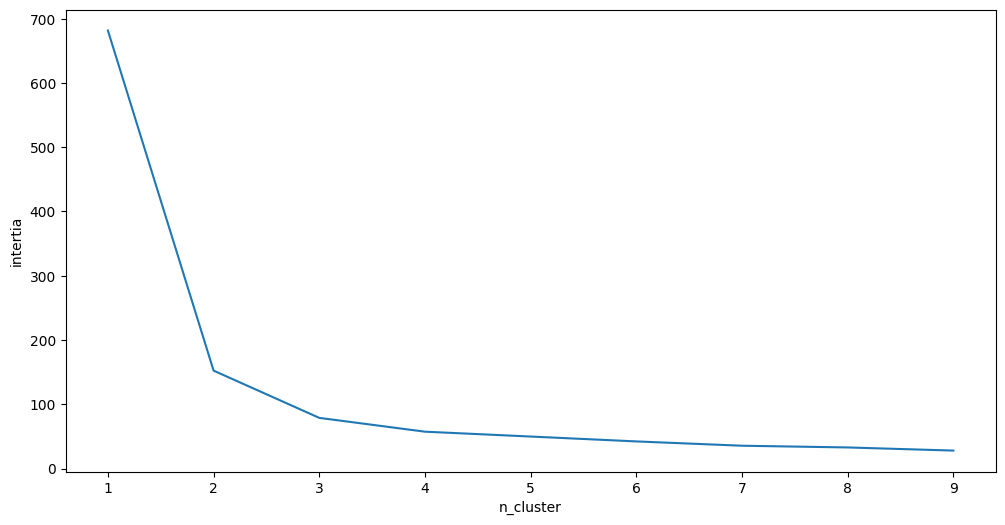

In [4]:
fig, ax = plt.subplots(1,1,figsize=(12,6))

ax.set_ylabel("intertia")
ax.set_xlabel("n_cluster")

ax = plt.plot(k_list, intertia_list)


In [5]:
# On charge le dataset iris : 
iris = datasets.load_iris()

# On extrait X : 
X = iris.data

# On peut le transformer en DataFrame : 
X = pd.DataFrame(X)

# Cela permet d'appliquer la méthode .head : 
X.head()

,0,1,2,3
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [8]:
Z = linkage(X, method="ward")

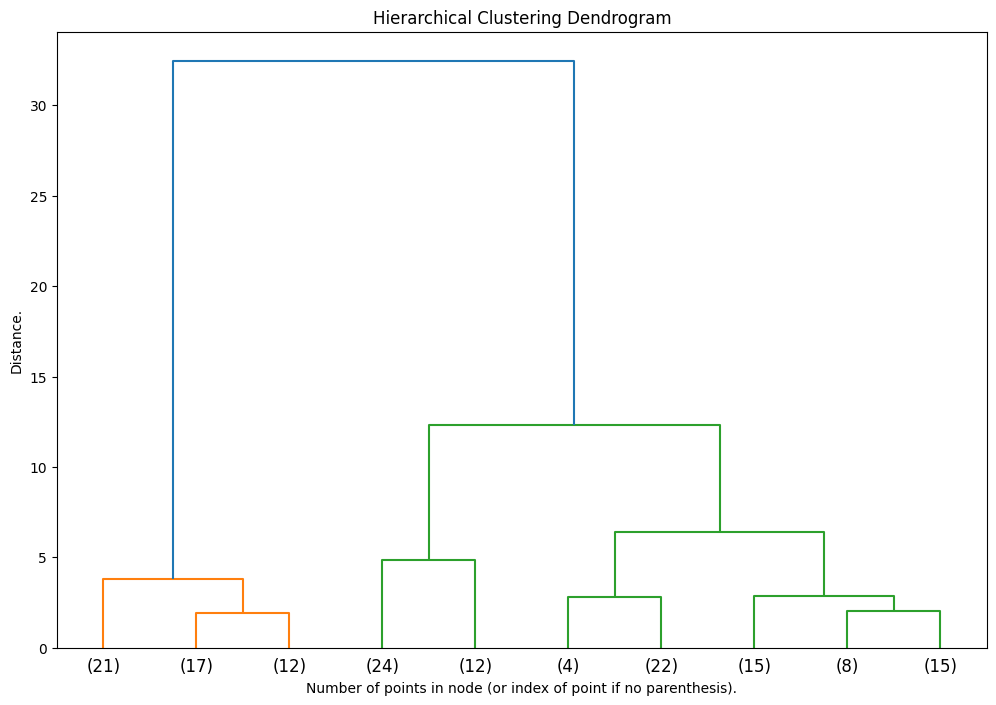

In [9]:
fig, ax = plt.subplots(1, 1, figsize=(12, 8))

_ = dendrogram(Z, p=10, truncate_mode="lastp", ax=ax)

plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Number of points in node (or index of point if no parenthesis).")
plt.ylabel("Distance.")
plt.show()

In [11]:
# On charge le dataset iris : 
iris = datasets.load_iris()

# On extrait X : 
X = iris.data

# On le transforme en DataFrame pour pouvoir mieux visualiser nos données : 
X = pd.DataFrame(X)
X.head()

,0,1,2,3
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [19]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       150 non-null    float64
 1   1       150 non-null    float64
 2   2       150 non-null    float64
 3   3       150 non-null    float64
dtypes: float64(4)
memory usage: 4.8 KB


In [14]:
# On instancie notre Kmeans avec 3 clusters : 
kmeans = KMeans(n_clusters=3)

# On l'entraine : 
kmeans.fit(X)

# On peut stocker nos clusters dans une variable labels : 
labels = kmeans.labels_
labels

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 2, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 0, 0, 0, 0, 2, 0, 0, 0,
       0, 0, 0, 2, 2, 0, 0, 0, 0, 2, 0, 2, 0, 2, 0, 0, 2, 2, 0, 0, 0, 0,
       0, 2, 0, 0, 0, 0, 2, 0, 0, 0, 2, 0, 0, 0, 2, 0, 0, 2], dtype=int32)

In [15]:
# On peut stocker nos centroids dans une variable : 
centroids = kmeans.cluster_centers_
centroids

array([[6.85384615, 3.07692308, 5.71538462, 2.05384615],
       [5.006     , 3.428     , 1.462     , 0.246     ],
       [5.88360656, 2.74098361, 4.38852459, 1.43442623]])

In [16]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [22]:
pca = PCA(n_components=4)
pca.fit(X_scaled)


,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",4
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized SVD 

In [24]:
X_proj = pca.transform(X_scaled)
X_proj = pd.DataFrame(X_proj, columns = ["PC1", "PC2", "PC3", "PC4"])
X_proj[:10]


,PC1,PC2,PC3,PC4
0,-2.264703,0.480027,0.127706,-0.024168
1,-2.080961,-0.674134,0.234609,-0.103007
2,-2.364229,-0.341908,-0.044201,-0.028377
3,-2.299384,-0.597395,-0.091290,0.065956
4,-2.389842,0.646835,-0.015738,0.035923
5,-2.075631,1.489178,-0.026968,-0.006608
6,-2.444029,0.047644,-0.335470,0.036776
7,-2.232847,0.223148,0.088695,0.024612
8,-2.334640,-1.115328,-0.145077,0.026859
9,-2.184328,-0.469014,0.253766,0.039899


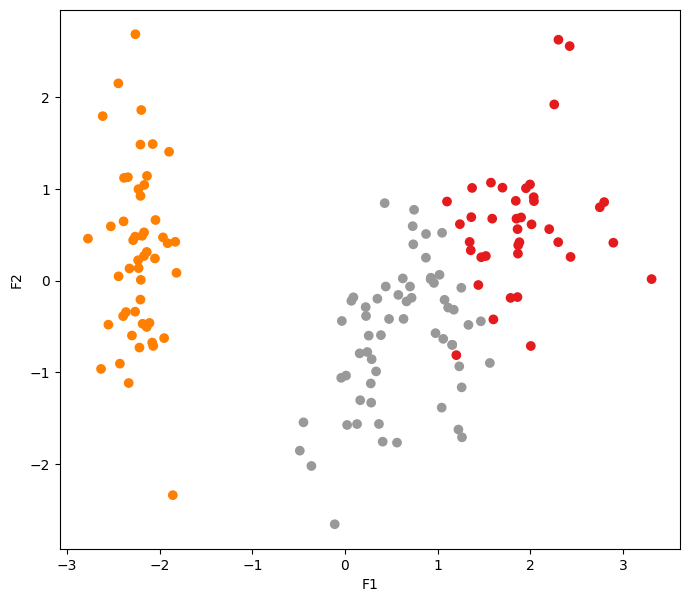

In [25]:
fig, ax = plt.subplots(1,1, figsize=(8,7))
ax.scatter(X_proj.iloc[:, 0], X_proj.iloc[:, 1], c= labels, cmap="Set1")
ax.set_xlabel("F1")
ax.set_ylabel("F2")
plt.show()

In [26]:
# On utilise bien le scaler déjà entrainé : 
centroids_scaled = scaler.fit_transform(centroids)

# et on utilise l'ACP déjà entrainée : 
centroids_proj = pca.transform(centroids_scaled)

# Création d'un dataframe pour plus de clarté:
centroids_proj = pd.DataFrame(centroids_proj, 
                              columns = ["F1", "F2", "F3", "F4"], 
                              index=["cluster_0", "cluster_1", "cluster_2"])

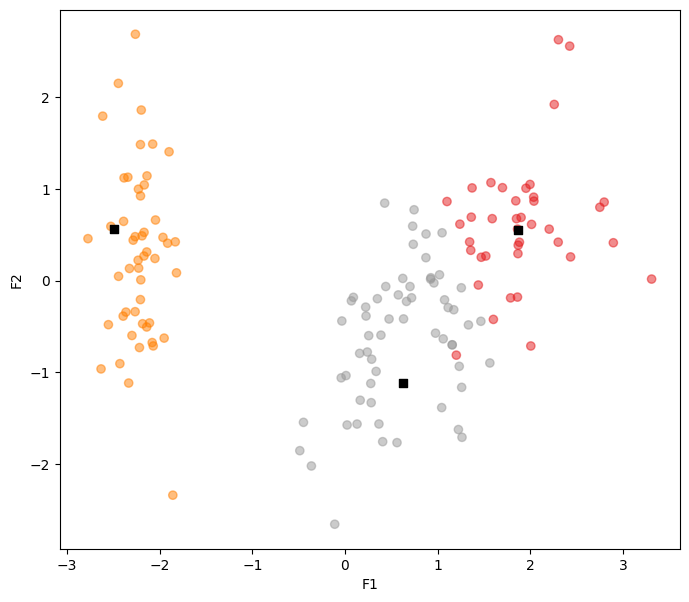

In [27]:
# On définit notre figure et son axe : 
fig, ax = plt.subplots(1,1, figsize=(8,7))

# On affiche nos individus, avec une transparence de 50% (alpha=0.5) : 
ax.scatter(X_proj.iloc[:, 0], X_proj.iloc[:, 1], c= labels, cmap="Set1", alpha =0.5)

# On affiche nos centroides, avec une couleur noire (c="black") et une frome de carré (marker="c") : 
ax.scatter(centroids_proj.iloc[:, 0], centroids_proj.iloc[:, 1],  marker="s", c="black" )

# On spécifie les axes x et y :
ax.set_xlabel("F1")
ax.set_ylabel("F2")
plt.show()

Text(0.5, 0, 'F3')

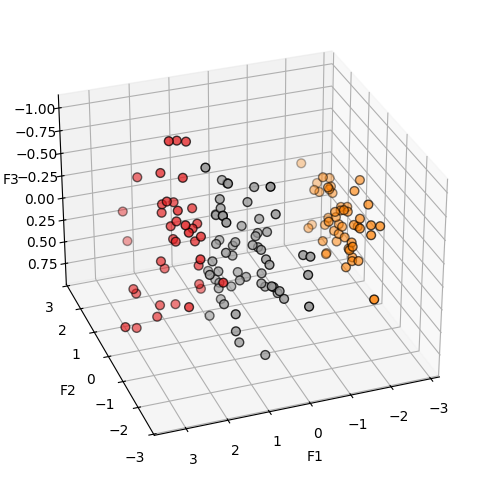

In [28]:
# On définit notre figure et notre axe différemment : 
fig= plt.figure(1, figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d", elev=-150, azim=110)

# On affiche nos points : 
ax.scatter(
    X_proj.iloc[:, 0],
    X_proj.iloc[:, 1],
    X_proj.iloc[:, 2],
    c=labels, cmap="Set1", edgecolor="k", s=40)

# On spécifie le nom des axes : 
ax.set_xlabel("F1")
ax.set_ylabel("F2")
ax.set_zlabel("F3")